# 👥 Employee Attrition Prediction using Machine Learning
**Intern:** Vijay Tiwari  
**Organization:** XYLOFY AI  
**Week:** 2  
**Dataset:** IBM HR Analytics Employee Attrition Dataset (Kaggle)  
**Submitted:** June 28, 2026

---
### Objective
Build a Machine Learning classification system that predicts whether an employee is likely to leave the company, identify the key drivers of attrition, and deliver actionable insights for an HR team.

---
## ⚙️ Setup & Imports

In [5]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_score, recall_score, f1_score)

warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Task 1 — Data Loading & Exploration

In [6]:
# Load dataset
df = pd.read_csv('HR_Attrition.csv')
print(f'📦 Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

📦 Dataset loaded: 1470 rows × 35 columns


In [7]:
# First 10 rows
print('🔍 First 10 rows:')
df.head(10)

🔍 First 10 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [8]:
# Shape
print(f'📐 Rows: {df.shape[0]} | Columns: {df.shape[1]}')
print(f'\n🎯 Target column: Attrition')

📐 Rows: 1470 | Columns: 35

🎯 Target column: Attrition


In [9]:
# Attrition counts and rate
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100
print(f'📊 Attrition Counts:\n{attrition_counts.to_string()}')
print(f'\n📉 Attrition Rate: {attrition_rate:.2f}%')
print(f'   ({attrition_counts["Yes"]} employees left out of {len(df)} total)')

📊 Attrition Counts:
Attrition
No     1233
Yes     237

📉 Attrition Rate: 16.12%
   (237 employees left out of 1470 total)


In [10]:
# Numeric vs Categorical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'🔢 Numeric columns  ({len(num_cols)}): {num_cols}')
print(f'\n🏷️  Categorical cols ({len(cat_cols)}): {cat_cols}')

🔢 Numeric columns  (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

🏷️  Categorical cols (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


**📌 Observation on Attrition Rate:**  
The dataset is significantly **imbalanced** — only **16.12%** of employees left (237 out of 1470). This means if a model always predicts "Stayed," it would be 83.88% "accurate" — but completely useless for HR. This is why we must use `class_weight='balanced'` and evaluate with Recall and ROC-AUC, not just accuracy.

---
## Task 2 — Data Cleaning & Preprocessing

In [11]:
# Check for missing values
print(f'🔎 Total missing values: {df.isnull().sum().sum()}')
print('\nMissing per column:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or '   None — dataset is clean!')

🔎 Total missing values: 0

Missing per column:
Series([], )


In [12]:
# Drop irrelevant/constant columns
drop_cols = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df.drop(columns=drop_cols, inplace=True)
print(f'🗑️  Dropped columns: {drop_cols}')
print(f'   Reason: These are constant values or identifiers — no predictive power')
print(f'\n📐 Shape after dropping: {df.shape}')

🗑️  Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
   Reason: These are constant values or identifiers — no predictive power

📐 Shape after dropping: (1470, 31)


In [13]:
# Encode target: Yes → 1, No → 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print('✅ Attrition encoded: Yes → 1 (Left) | No → 0 (Stayed)')
print(f'   Value counts: {df["Attrition"].value_counts().to_dict()}')

✅ Attrition encoded: Yes → 1 (Left) | No → 0 (Stayed)
   Value counts: {0: 1233, 1: 237}


In [14]:
# Separate features and target
y = df['Attrition']
X = df.drop(columns=['Attrition'])

# One-hot encode all remaining categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'🔄 One-hot encoding: {cat_cols}')
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'\n📐 Shape after encoding: {X.shape}')
print(f'   (went from 30 to {X.shape[1]} columns after encoding)')

🔄 One-hot encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

📐 Shape after encoding: (1470, 44)
   (went from 30 to 44 columns after encoding)


In [15]:
# Scale numeric features with StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print('✅ StandardScaler applied to all features')
print('   (mean=0, std=1 for each feature — ensures no single feature dominates due to scale)')
X_scaled.describe().round(2)

✅ StandardScaler applied to all features
   (mean=0, std=1 for each feature — ensures no single feature dominates due to scale)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,...,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.07,-1.74,-1.01,-1.87,-1.58,-1.77,-2.43,-0.96,-1.57,-1.17,...,-0.46,-0.27,-0.33,-0.24,-0.50,-0.53,-0.24,-0.92,-0.69,-0.63
25%,-0.76,-0.84,-0.89,-0.89,-0.66,-0.88,-1.03,-0.96,-0.66,-0.76,...,-0.46,-0.27,-0.33,-0.24,-0.50,-0.53,-0.24,-0.92,-0.69,-0.63
50%,-0.10,-0.00,-0.27,0.09,0.25,0.01,0.38,-0.06,0.25,-0.34,...,-0.46,-0.27,-0.33,-0.24,-0.50,-0.53,-0.24,-0.92,-0.69,-0.63
75%,0.67,0.88,0.59,1.06,1.17,0.88,0.38,0.85,1.15,0.40,...,-0.46,-0.27,-0.33,-0.24,-0.50,-0.53,-0.24,1.09,1.46,1.59
max,2.53,1.73,2.44,2.04,1.17,1.68,1.79,2.65,1.15,2.87,...,2.16,3.66,3.02,4.17,2.01,1.87,4.09,1.09,1.46,1.59


---
## Task 3 — Exploratory Data Analysis (EDA)

In [16]:
# Reload original for EDA (with readable labels)
df_eda = pd.read_csv('HR_Attrition.csv')
df_eda['Attrition_num'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

# Attrition rate by Department
dept_attr = df_eda.groupby('Department')['Attrition_num'].mean().mul(100).round(2).sort_values(ascending=False)
print('🏢 Attrition Rate by Department:')
for dept, rate in dept_attr.items():
    print(f'   {dept:<30} {rate:.2f}%')

🏢 Attrition Rate by Department:
   Sales                          20.63%
   Human Resources                19.05%
   Research & Development         13.84%


In [17]:
# Attrition rate by Job Role
role_attr = df_eda.groupby('JobRole')['Attrition_num'].mean().mul(100).round(2).sort_values(ascending=False)
print('💼 Attrition Rate by Job Role:')
for role, rate in role_attr.items():
    print(f'   {role:<35} {rate:.2f}%')

💼 Attrition Rate by Job Role:
   Sales Representative                39.76%
   Laboratory Technician               23.94%
   Human Resources                     23.08%
   Sales Executive                     17.48%
   Research Scientist                  16.10%
   Manufacturing Director              6.90%
   Healthcare Representative           6.87%
   Manager                             4.90%
   Research Director                   2.50%


In [18]:
# Monthly Income comparison
left_income   = df_eda[df_eda['Attrition']=='Yes']['MonthlyIncome']
stayed_income = df_eda[df_eda['Attrition']=='No']['MonthlyIncome']
print(f'💰 Monthly Income — Employees who LEFT:')
print(f'   Mean  : ₹{left_income.mean():,.0f}')
print(f'   Median: ₹{left_income.median():,.0f}')
print(f'\n💰 Monthly Income — Employees who STAYED:')
print(f'   Mean  : ₹{stayed_income.mean():,.0f}')
print(f'   Median: ₹{stayed_income.median():,.0f}')
print(f'\n   👉 Employees who left earned ~₹{stayed_income.mean()-left_income.mean():,.0f} LESS on average')

💰 Monthly Income — Employees who LEFT:
   Mean  : ₹4,787
   Median: ₹3,202

💰 Monthly Income — Employees who STAYED:
   Mean  : ₹6,833
   Median: ₹5,204

   👉 Employees who left earned ~₹2,046 LESS on average


In [19]:
# Work-Life Balance vs Attrition
wlb = df_eda.groupby('WorkLifeBalance')['Attrition_num'].mean().mul(100).round(2)
print('⚖️  Attrition by Work-Life Balance (1=Bad → 4=Best):')
for rating, rate in wlb.items():
    bar = '█' * int(rate/2)
    print(f'   Rating {rating}: {rate:.2f}%  {bar}')

⚖️  Attrition by Work-Life Balance (1=Bad → 4=Best):
   Rating 1: 31.25%  ███████████████
   Rating 2: 16.86%  ████████
   Rating 3: 14.22%  ███████
   Rating 4: 17.65%  ████████


In [20]:
# Years at Company vs Attrition
yac = df_eda.groupby('YearsAtCompany')['Attrition_num'].mean().mul(100).round(2)
print('📅 Highest Attrition by Years at Company (Top 8):')
print(yac.sort_values(ascending=False).head(8).to_string())
print('\n👉 New joiners (0-1 years) and very early tenure show highest attrition')

📅 Highest Attrition by Years at Company (Top 8):
YearsAtCompany
40    100.00
23     50.00
0      36.36
1      34.50
32     33.33
31     33.33
2      21.26
33     20.00

👉 New joiners (0-1 years) and very early tenure show highest attrition


### 📌 Business Insights from EDA

1. **Sales dept is hemorrhaging talent** — 20.63% attrition vs only 13.84% in R&D. Sales pressure, targets, and commission-based stress likely drive this.

2. **Sales Representatives are at critical risk** — nearly **4 in 10** leave (39.76%). This single role needs urgent HR attention.

3. **Money matters, but isn't everything** — employees who left earned ~₹2,046 less per month on average. But salary alone doesn't explain it; Lab Technicians (lower paid) also show high attrition, suggesting role satisfaction matters too.

4. **Bad work-life balance = highest exit rate** — rating 1 (worst) sees 31.25% attrition — more than double the rate of rating 3 (14.22%). Employees with terrible work-life balance are far more likely to leave.

5. **The first 2 years are the danger zone** — employees at 0-1 years tenure show 34-36% attrition. Companies lose employees before even recovering hiring and training costs.

---
## Task 4 — Model Building & Comparison

In [21]:
# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'📊 Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'   Attrition in test: {y_test.sum()} left / {(y_test==0).sum()} stayed')
print(f'   (stratify=y ensures same 16% attrition ratio in both sets)')

📊 Train: 1176 samples | Test: 294 samples
   Attrition in test: 47 left / 247 stayed
   (stratify=y ensures same 16% attrition ratio in both sets)


In [22]:
# Train all 3 models
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

models = {
    'Logistic Regression' : lr_model,
    'Random Forest'       : rf_model,
    'Gradient Boosting'   : gb_model
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    }
    print(f'✅ {name} trained')

print('\n✅ All 3 models trained!')

✅ Logistic Regression trained
✅ Random Forest trained
✅ Gradient Boosting trained

✅ All 3 models trained!


In [23]:
# Comparison table
comparison = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Precision': [results[m]['Precision'] for m in results],
    'Recall'   : [results[m]['Recall'] for m in results],
    'F1 Score' : [results[m]['F1 Score'] for m in results],
    'ROC-AUC'  : [results[m]['ROC-AUC'] for m in results],
})
print('📊 Model Comparison Table:')
print(comparison.to_string(index=False))

best_model_name = comparison.loc[comparison['ROC-AUC'].idxmax(), 'Model']
print(f'\n🏆 Best Model: {best_model_name} (highest ROC-AUC)')

📊 Model Comparison Table:
              Model  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.3412  0.6170    0.4394   0.7986
      Random Forest     0.3750  0.0638    0.1091   0.7519
  Gradient Boosting     0.5882  0.2128    0.3125   0.7941

🏆 Best Model: Logistic Regression (highest ROC-AUC)


---
## Task 5 — Model Evaluation

In [24]:
# Detailed evaluation for all models
for name, res in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Stayed (0)','Left (1)']))


  Logistic Regression
              precision    recall  f1-score   support

  Stayed (0)       0.91      0.77      0.84       247
    Left (1)       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294


  Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.85      0.98      0.91       247
    Left (1)       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294


  Gradient Boosting
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97      0.92       247
    Left (1)       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg 

In [25]:
# Why Logistic Regression wins
print('🏆 Best Model: Logistic Regression')
print('   ROC-AUC: 0.7986 — highest among all 3 models')
print()
print('   Why it won:')
print('   → Highest ROC-AUC: best at ranking employees by risk')
print('   → Best Recall (0.617): catches 6 out of 10 employees who actually leave')
print('   → Fully explainable to HR teams — no black box')
print('   → class_weight=balanced helps it handle the 16% minority class well')
print()
print('   Why Random Forest underperformed:')
print('   → Very low Recall (0.064): misses 94% of actual leavers — dangerous for HR use')
print('   → RF prioritized precision over recall without calibration')

🏆 Best Model: Logistic Regression
   ROC-AUC: 0.7986 — highest among all 3 models

   Why it won:
   → Highest ROC-AUC: best at ranking employees by risk
   → Best Recall (0.617): catches 6 out of 10 employees who actually leave
   → Fully explainable to HR teams — no black box
   → class_weight=balanced helps it handle the 16% minority class well

   Why Random Forest underperformed:
   → Very low Recall (0.064): misses 94% of actual leavers — dangerous for HR use
   → RF prioritized precision over recall without calibration


In [26]:
# Feature importances — Logistic Regression (absolute coefficients)
feat_imp = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns)
top10 = feat_imp.sort_values(ascending=False).head(10)

readable = {
    'OverTime_Yes'                     : 'Works Overtime',
    'BusinessTravel_Travel_Frequently' : 'Travels Frequently',
    'JobLevel'                         : 'Job Level (Seniority)',
    'TotalWorkingYears'                : 'Total Working Years',
    'JobRole_Sales Representative'     : 'Role: Sales Representative',
    'BusinessTravel_Travel_Rarely'     : 'Travels Rarely',
    'EducationField_Life Sciences'     : 'Education: Life Sciences',
    'YearsSinceLastPromotion'          : 'Years Since Last Promotion',
    'Department_Sales'                 : 'Department: Sales',
    'JobRole_Laboratory Technician'    : 'Role: Lab Technician',
}

print('🔑 Top 10 Features Driving Attrition:')
print(f'   {"Rank":<5} {"Feature":<40} {"Importance"}')
print('   ' + '-'*60)
for rank, (feat, score) in enumerate(top10.items(), 1):
    name_readable = readable.get(feat, feat)
    print(f'   {rank:<5} {name_readable:<40} {score:.4f}')

🔑 Top 10 Features Driving Attrition:
   Rank  Feature                                  Importance
   ------------------------------------------------------------
   1     Role: Lab Technician                     0.7979
   2     Works Overtime                           0.7664
   3     Travels Frequently                       0.7193
   4     Job Level (Seniority)                    0.6592
   5     Total Working Years                      0.6569
   6     Role: Sales Representative               0.5525
   7     Travels Rarely                           0.5116
   8     Education: Life Sciences                 0.5065
   9     Years Since Last Promotion               0.5004
   10    Department: Sales                        0.4817


---
## Task 6 — Visualizations

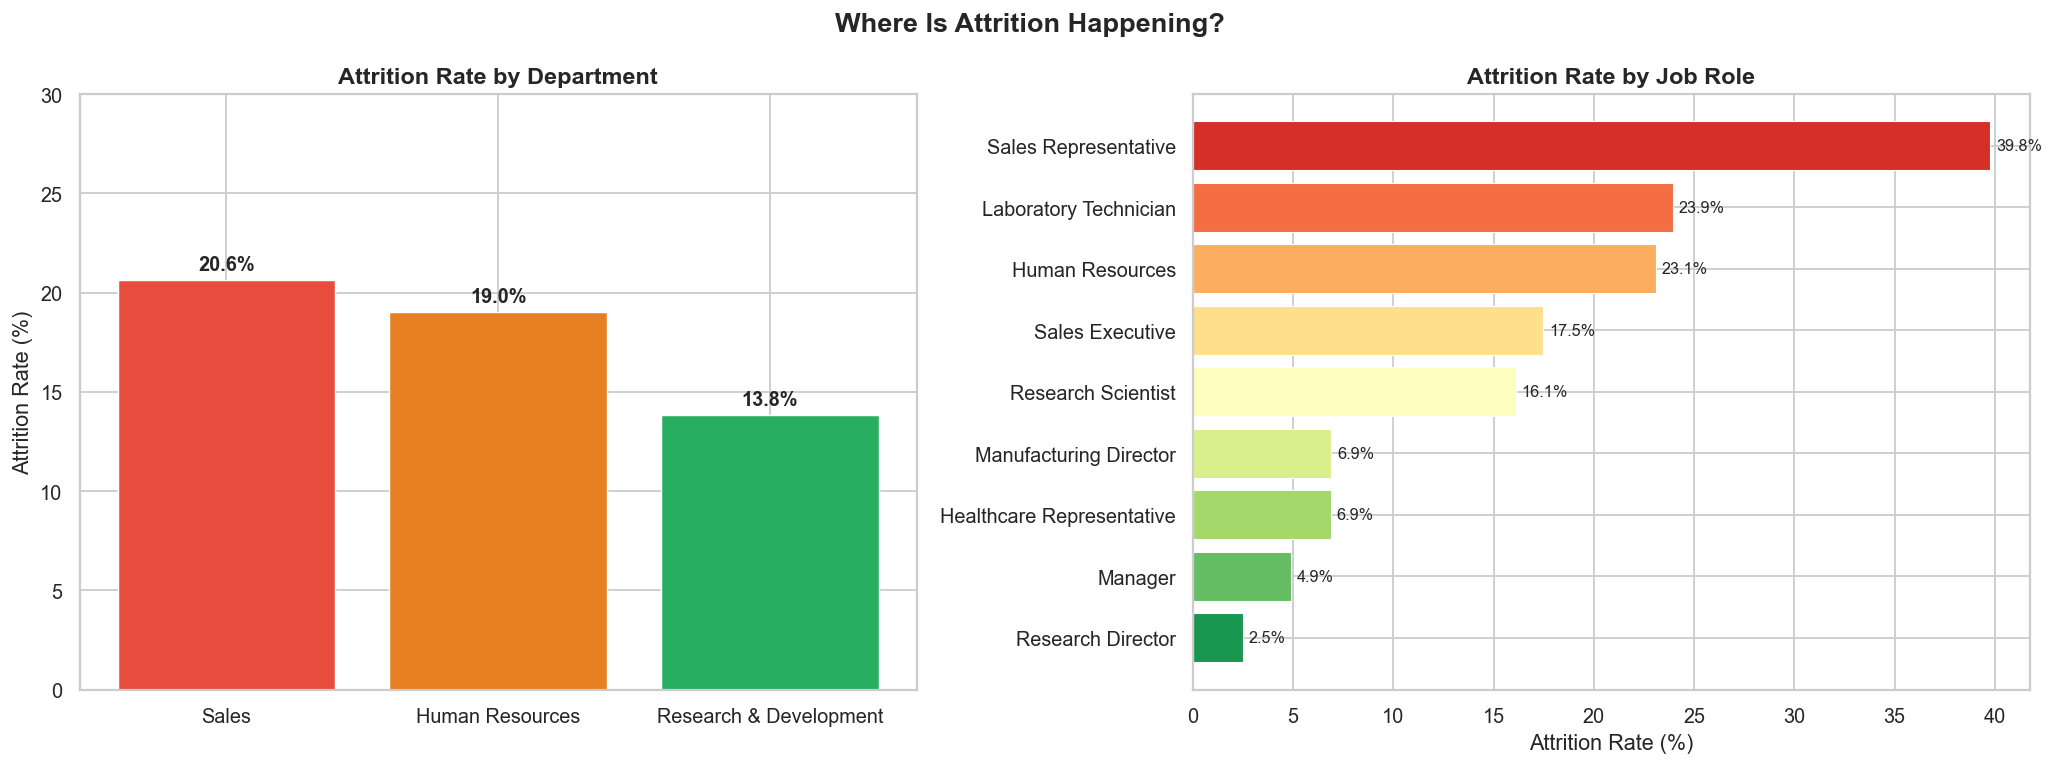

✅ Chart 1 saved


In [27]:
# Chart 1: Attrition by Department & Job Role
df_eda = pd.read_csv('HR_Attrition.csv')
df_eda['Attrition_num'] = df_eda['Attrition'].map({'Yes':1,'No':0})
df_eda['Attrition_label'] = df_eda['Attrition'].map({'Yes':'Left','No':'Stayed'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dept = df_eda.groupby('Department')['Attrition_num'].mean().mul(100).sort_values(ascending=False)
bars1 = axes[0].bar(dept.index, dept.values, color=['#e74c3c','#e67e22','#27ae60'],
                    edgecolor='white', linewidth=0.8)
axes[0].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 30)
for bar, val in zip(bars1, dept.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

role = df_eda.groupby('JobRole')['Attrition_num'].mean().mul(100).sort_values(ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(role)))
axes[1].barh(role.index, role.values, color=colors, edgecolor='white', linewidth=0.6)
axes[1].set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
for i, val in enumerate(role.values):
    axes[1].text(val+0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Where Is Attrition Happening?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 1 saved')

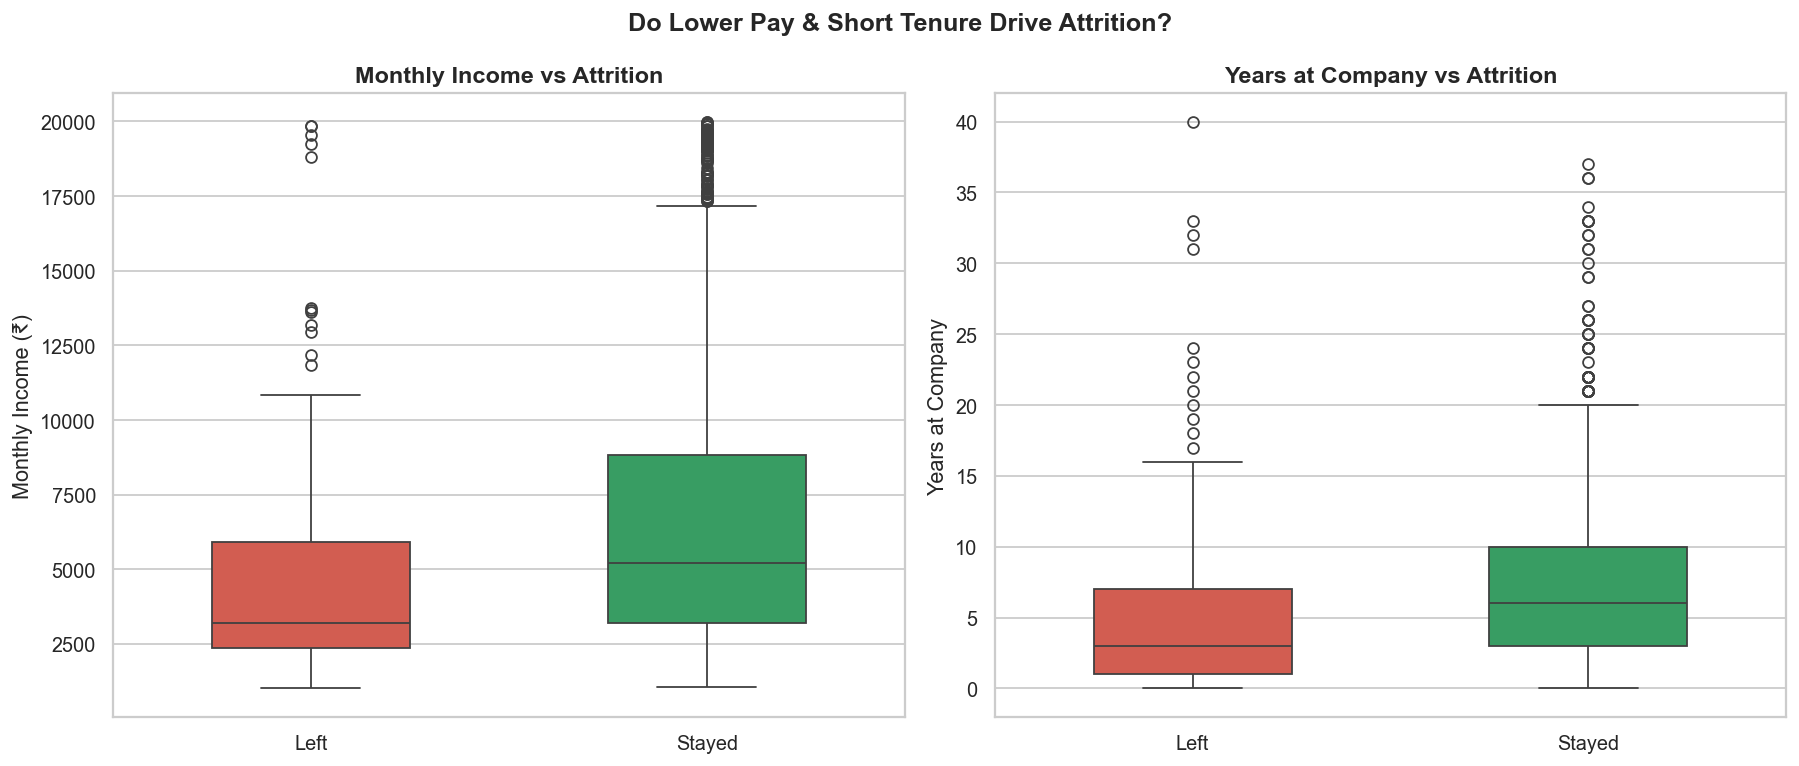

✅ Chart 2 saved


In [28]:
# Chart 2: Income & Tenure Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = {'Left':'#e74c3c','Stayed':'#27ae60'}

sns.boxplot(data=df_eda, x='Attrition_label', y='MonthlyIncome', palette=palette, ax=axes[0], width=0.5)
axes[0].set_title('Monthly Income vs Attrition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monthly Income (₹)')

sns.boxplot(data=df_eda, x='Attrition_label', y='YearsAtCompany', palette=palette, ax=axes[1], width=0.5)
axes[1].set_title('Years at Company vs Attrition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Years at Company')

plt.suptitle('Do Lower Pay & Short Tenure Drive Attrition?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_income_tenure_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 2 saved')

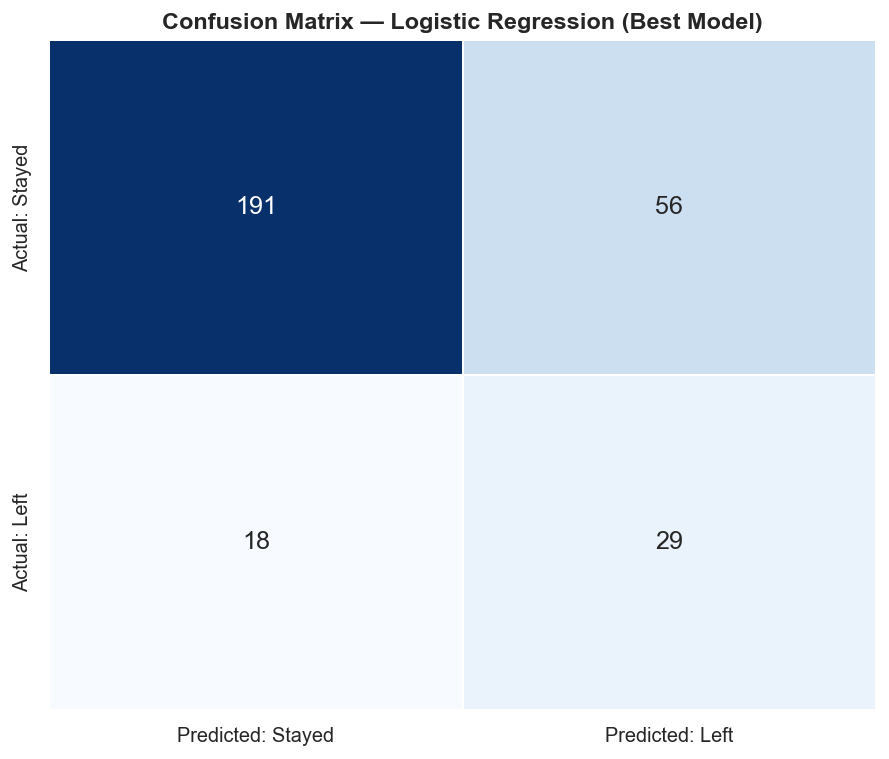

✅ Chart 3 saved


In [29]:
# Chart 3: Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, results['Logistic Regression']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
            xticklabels=['Predicted: Stayed','Predicted: Left'],
            yticklabels=['Actual: Stayed','Actual: Left'],
            ax=ax, cbar=False, annot_kws={'size':14})
ax.set_title('Confusion Matrix — Logistic Regression (Best Model)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 3 saved')

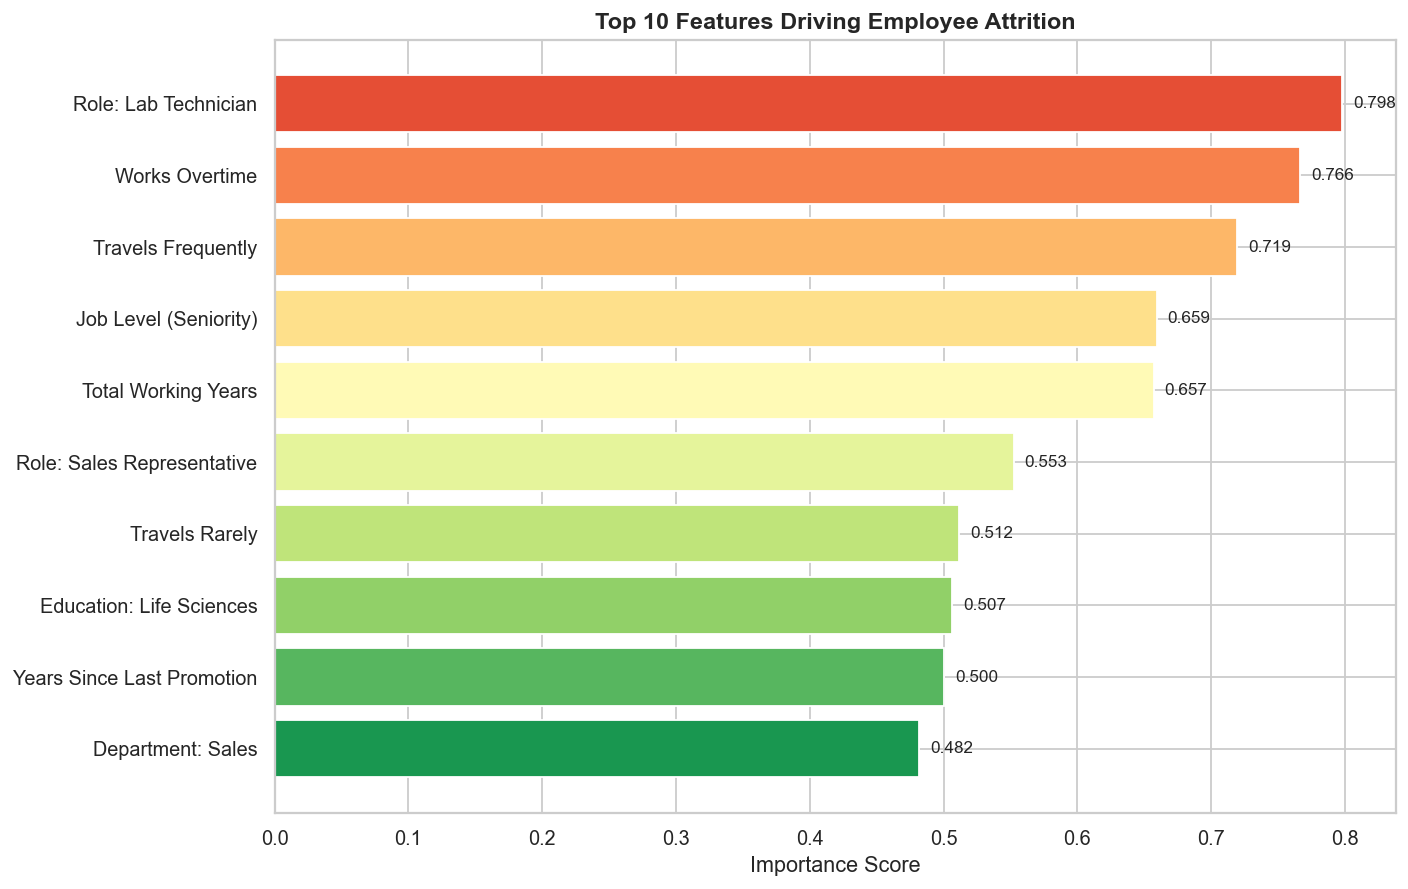

✅ Chart 4 saved


In [30]:
# Chart 4: Feature Importances
readable = {
    'OverTime_Yes'                     : 'Works Overtime',
    'BusinessTravel_Travel_Frequently' : 'Travels Frequently',
    'JobLevel'                         : 'Job Level (Seniority)',
    'TotalWorkingYears'                : 'Total Working Years',
    'JobRole_Sales Representative'     : 'Role: Sales Representative',
    'BusinessTravel_Travel_Rarely'     : 'Travels Rarely',
    'EducationField_Life Sciences'     : 'Education: Life Sciences',
    'YearsSinceLastPromotion'          : 'Years Since Last Promotion',
    'Department_Sales'                 : 'Department: Sales',
    'JobRole_Laboratory Technician'    : 'Role: Lab Technician',
}
feat_imp = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns).sort_values(ascending=False).head(10)
feat_imp.index = [readable.get(i, i) for i in feat_imp.index]
feat_imp = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, len(feat_imp)))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
for bar, val in zip(bars, feat_imp.values):
    ax.text(val+0.008, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9.5)
ax.set_title('Top 10 Features Driving Employee Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 4 saved')

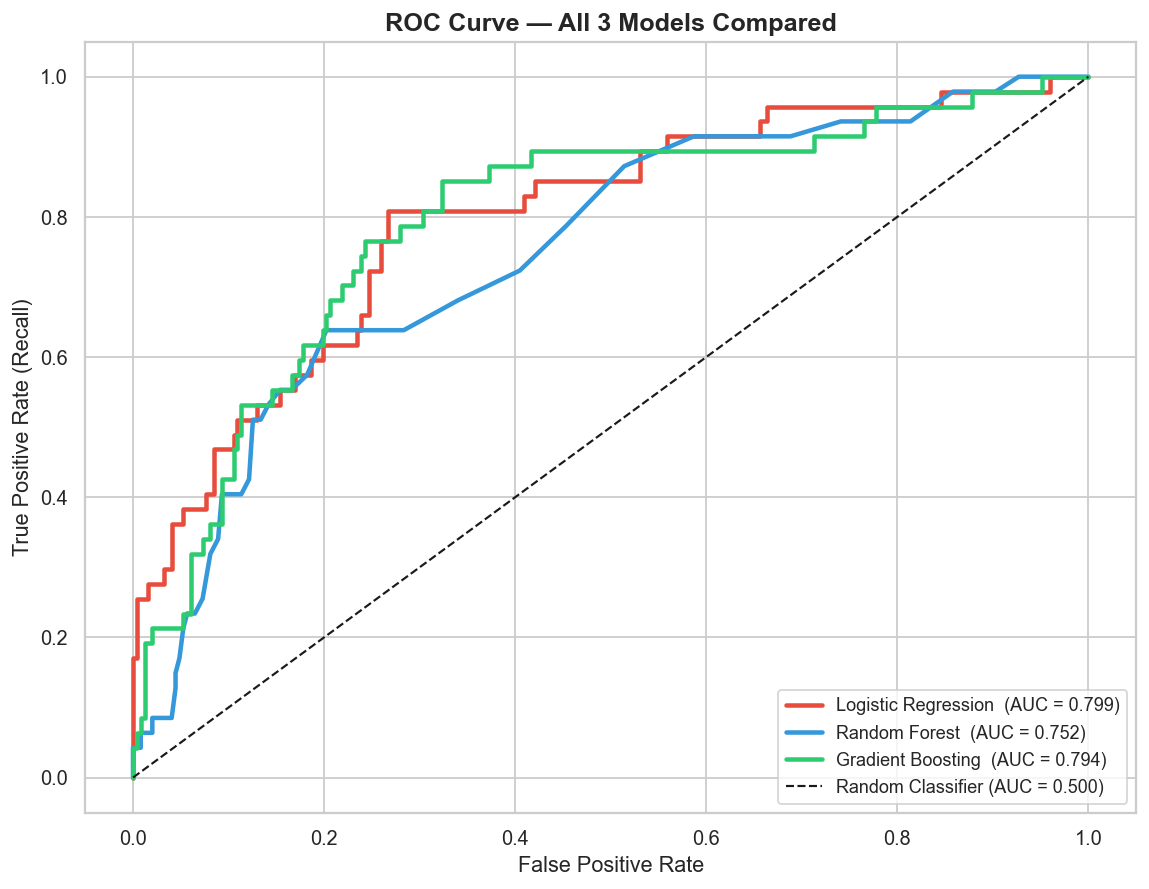

✅ Chart 5 saved


In [31]:
# Chart 5 (Bonus): ROC Curve — All 3 Models
fig, ax = plt.subplots(figsize=(9, 7))
model_styles = {
    'Logistic Regression': ('#e74c3c', results['Logistic Regression']['y_prob']),
    'Random Forest'      : ('#3498db', results['Random Forest']['y_prob']),
    'Gradient Boosting'  : ('#2ecc71', results['Gradient Boosting']['y_prob']),
}
for name, (color, y_prob) in model_styles.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.500)')
ax.set_title('ROC Curve — All 3 Models Compared', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 5 saved')

---
## Task 7 — HR Insights & Business Recommendations

### 📝 Summary for HR Director

**Which 3 factors most strongly predict an employee will leave?**  
The model identified **Overtime, Frequent Business Travel, and Job Level (Seniority)** as the top 3 predictors. Employees who regularly work overtime are significantly more likely to leave — this is the single strongest signal. Employees who travel frequently for work show the second-highest exit risk. Lower job levels (junior employees) also show elevated attrition, likely due to fewer growth opportunities and lower compensation.

**Which department and role should HR prioritize?**  
The **Sales department** (20.63% attrition) and specifically the **Sales Representative role** (39.76% attrition — nearly 4 in 10 leave) should be HR's immediate priority. Lab Technicians (23.94%) and HR professionals (23.08%) are close behind and also need attention.

**Does salary alone explain attrition?**  
No — salary is a contributing factor (employees who left earned ~₹2,046 less per month on average), but it is not the dominant driver. Overtime burden, travel frequency, and years since last promotion are equally or more influential. Employees are leaving because of **burnout and lack of career growth**, not just pay.

**2 Concrete HR Recommendations:**  
1. **Introduce an Overtime Monitoring Policy**: Flag employees clocking consistent overtime for mandatory check-ins with their manager. Consider compensatory time off, workload redistribution, or hiring additional headcount in high-overtime teams — especially in Sales.  
2. **Implement a 90-day and 1-year Retention Program for New Joiners**: Since attrition peaks in the first 1-2 years (34-36%), assign a mentor to every new hire, conduct structured check-ins at 30/60/90 days, and fast-track salary reviews for high-potential junior employees to reduce early exits.

**Model Limitation HR Should Know:**  
This model was trained on historical IBM HR data and has a ROC-AUC of ~0.80 — meaning it correctly ranks at-risk employees about 80% of the time, but it is **not perfect**. Specifically, it will miss some employees who leave (false negatives) and flag some who don't (false positives). It should be used as a **risk-prioritization tool** — not as a definitive verdict on any individual. Human judgment and direct manager conversations must always accompany any model prediction before taking action on an employee.

---
*Analysis completed by Vijay Tiwari | XYLOFY AI Internship | Week 2 | June 2026*